In [2]:
%%capture cap
%run desp-authentication.py

Username:  qinghuai925
Password:  ········


In [3]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

In [4]:
from pyproj import datadir
import earthkit.data
import earthkit.plots
import earthkit.regrid
from polytope.api import Client

import os
import os.path  # for basename
import sys
import glob
from pathlib import Path
import warnings
import datetime
import time  # for sleep

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from netCDF4 import Dataset
from PIL import Image

from mpl_toolkits.basemap import Basemap

import rasterio
from rasterio.transform import from_origin
from rasterio.merge import merge

from osgeo import gdal, osr, ogr  # Python bindings for GDAL
from global_land_mask import globe
from scipy.interpolate import griddata

from tqdm.auto import tqdm
from dask.diagnostics import ProgressBar

# utilities you mentioned using
from numpy import savetxt
import calendar

/work/data/zhang/anaconda3/envs/earthkit/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [5]:
# repo root: NOCOSRIOgit
repo_root = Path.cwd().resolve().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [6]:
from common import download_icedata_c
from common import data_fetching
from common import config
from common import processing
from common.download_icedata_c import request_icedata_subarea

In [7]:
def request_icedata_subarea(activity,experiment,model,date,subarea,param,datadir=None):
	"""
	This function retrieves ClimateDT data
	#####
	- If a datadir is given, the function checks whether the desired data is already existing there.
	- Otherwise it will send a request to Polytope.
	- If a datadir is given and data was not existing there, the downloaded data will be saved for later use.
    
    Example usage:
    dataICE=request_icedata_subarea(activity="CMIP6",experiment="hist",model="ICON",
                                    date="2002-02-28",subarea="greenland", param="263001/263003/263004",
                                    datadir="/media/volume/")

    """
	
	# Set pre-defined download areas
	import earthkit.data
	if subarea in ["Greenland","greenland"]:
		area='85/-80/67/5'
	elif subarea in ["Arctic","arctic"]:
		area='90/-180/70/180'
	else:
		raise RuntimeError("Unknown subarea: "+ subarea+". Cannot create request.")
	
	# Check if data is already existing on disk
	filename='icedata_'+activity+'_'+experiment+'_'+model+'_'+date.replace("/","-")+'_'+subarea+'_'+param.replace("/","-")+'.grb'
	if datadir:
		print("Looking for previously downloaded data in: "+datadir)
		print("File name to look for: "+filename)
		try:
			dataICE=earthkit.data.from_source("file",datadir+"/"+filename)
		except FileNotFoundError:
			# File is not existing, hence download the data
			requestdata=True
		else:
			# No error, hence file was found, hence we don't need to download it
			print("Loading data from file:"+datadir+"/"+filename)
			requestdata=False
	else:
		requestdata=True
	
	# Request data from Polytope
	if requestdata==True: # No datadir given or file not existing in datadir => Will download data
		print("No datadir given or no existing data file found. I will request data from Polytope...")
		request = {
				"activity": activity,
				"class": "d1",
				"dataset": "climate-dt",
				"date": date,
				"experiment": experiment,
				"expver": "0001",
				"generation": "1",
				"levtype": "o2d",
				"model": model,
				"param": param,
				"realization": "1",
				"resolution": "high",
				"stream": "clte",
				"time": "0000",
				"type": "fc",
				'grid' : 'F512', # currently O, F, N grids are supported 
				'area' : area # e.g. '85/-80/67/5' # maxLAT, minLON, minLAT, maxLON
			}
		print(request)

		# Execute the download request
		#    data is an earthkit streaming object but with stream=False will download data immediately 
		dataICE = earthkit.data.from_source("polytope", "destination-earth", request, 
										address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)
	
		# Save data to disk for later use , if "datadir" is given
		if datadir:
			print("Saving data to: "+datadir+"/"+filename)
			dataICE.to_target("file",datadir+"/"+filename)
	
	return(dataICE)


In [8]:
def polaris(dattype,shipclass,season,*argv):
    if dattype == 'mod':
        if not len(argv)==3:
            raise RuntimeError("If DATTYPE is 'mod', then you have to provide 3 additional arguments: CCAT, HCAT and SCAT.")
        else:
            ccat=argv[0]
            hcat=argv[1]
            scat=argv[2]
        if np.sum(ccat) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    if dattype == 'modlim2':
        if not len(argv)==2:
            raise RuntimeError("If DATTYPE is 'modlim2', then you have to provide 2 additional arguments: CCAT and HCAT.")
        else:
            sic=argv[0]
            sit=argv[1]
        if np.sum(sic) < 0.99:
            raise RuntimeError("The ice concentrations in CCAT does not sum up to 100%. Did you forget to include the open water fraction?")
    elif dattype == 'hem':
        if not len(argv)==1:
            raise RuntimeError("If DATTYPE is 'hem', then you have to provide 1 additional argument: THICK")
        else:
            thick = argv[0]
    else:
        raise ValueError("DATTYPE has to be one of ['mod','modlim2','hem']")
                    
    if not (shipclass in ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']):
        raise ValueError("shipclass has to be one of ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','1ASuper','1A','1B','1C','noclass']")
    # http://joshuakugler.com/archives/30-BetweenDict,-a-Python-dict-for-value-ranges.html
    class BetweenDict(dict):
        def __init__(self, d = {}):
            for k,v in d.items():
                self[k] = v
    
        def lookup(self, key):
            for k, v in self.items():
                if k[0] <= key < k[1]:
                    return v
            warnings.warn("Key '%s' is not between any values in the BetweenDict" % key)
            return {np.nan:np.nan} # Return a dictionary so that rv.lookup(thi[icl])[shipclass] will raise a KeyError.
#AGI            raise KeyError("Key '%s' is not between any values in the BetweenDict" % key)
    
        def setrange(self, key, value):
            try:
                if len(key) == 2:
                    if key[0] < key[1]:
                        dict.__setitem__(self, (key[0], key[1]), value)
                    else:
                        raise RuntimeError('First element of a BetweenDict key '
                                           'must be strictly less than the '
                                           'second element')
                else:
                    raise ValueError('Key of a BetweenDict must be an iterable '
                                     'with length two')
            except TypeError:
                raise TypeError('Key of a BetweenDict must be an iterable '
                                 'with length two')
    
        def __contains__(self, key):
            try:
                return bool(self[key]) or True
            except KeyError:
                return False
    
    # RV summer
    rvs = BetweenDict()
    rvs.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvs.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvs.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvs.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvs.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvs.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvs.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # medium FY 1
    rvs.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 2
    rvs.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # thick FY
    rvs.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvs.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvs.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    # RV winter
    rvw = BetweenDict()
    rvw.setrange([0.  ,0.01],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':3,'PC7':3,  '1ASuper':3,'1A':3,'1B':3,'1C':3,'noclass':3}) # no ice
    rvw.setrange([0.01,0.10],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':2,'noclass':1}) # new ice
    rvw.setrange([0.10,0.15],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':2,'1C':1,'noclass':0}) # grey ice
    rvw.setrange([0.15,0.30],{'PC1':3,'PC2':3,'PC3':3,'PC4':3,'PC5':3,  'PC6':2,'PC7':2,  '1ASuper':2,'1A':2,'1B':1,'1C':0,'noclass':-1}) # grey-white
    rvw.setrange([0.30,0.50],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':2,'PC7':1,  '1ASuper':2,'1A':1,'1B':0,'1C':-1,'noclass':-2}) # thin FY 1
    rvw.setrange([0.50,0.70],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':2,  'PC6':1,'PC7':1,  '1ASuper':1,'1A':0,'1B':-1,'1C':-2,'noclass':-3}) # thin FY 2
    rvw.setrange([0.70,0.95],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':1,'PC7':0,  '1ASuper':0,'1A':-1,'1B':-2,'1C':-3,'noclass':-4}) # medium FY 1
    rvw.setrange([0.95,1.20],{'PC1':2,'PC2':2,'PC3':2,'PC4':2,'PC5':1,  'PC6':0,'PC7':-1,  '1ASuper':-1,'1A':-2,'1B':-3,'1C':-4,'noclass':-5}) # medium FY 2
    rvw.setrange([1.20,2.00],{'PC1':2,'PC2':2,'PC3':2,'PC4':1,'PC5':0,  'PC6':-1,'PC7':-2,  '1ASuper':-2,'1A':-3,'1B':-4,'1C':-5,'noclass':-6}) # thick FY
    rvw.setrange([2.00,2.50],{'PC1':2,'PC2':1,'PC3':1,'PC4':0,'PC5':-1,  'PC6':-2,'PC7':-3,  '1ASuper':-3,'1A':-4,'1B':-5,'1C':-6,'noclass':-7}) # Second year ice
    rvw.setrange([2.50,3.00],{'PC1':1,'PC2':1,'PC3':0,'PC4':-1,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-7,'noclass':-8}) # light MY
    rvw.setrange([3.00,99.9],{'PC1':1,'PC2':0,'PC3':-1,'PC4':-2,'PC5':-2,  'PC6':-3,'PC7':-3,  '1ASuper':-4,'1A':-5,'1B':-6,'1C':-8,'noclass':-8}) # heavy MY
    
    if season in ['w','winter']:
        rv = rvw
    elif season in ['s','summer']:
        rv = rvs
    else:
        raise ValueError("season has to be one of ['winter','summer','w','s']")       
   
    if dattype == 'mod':
        # Part for MOD
        ##############
        thi=hcat + scat
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for icl in range(len(ccat)): # 5 model ice categories
            try:
                rio += (10.*ccat[icl]) * rv.lookup(thi[icl])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
 
    elif dattype == 'modlim2':
        # Part for MOD, artificially constructed from LIM2 grid cells
        ###############
        # RIO = (C1xRV1)+(C2xRV2)+(C3xRV3)+...(CnxRVn)
        rio = 0.
        for cellnum in range(len(sic)): # 5 model ice categories
            try:
                rio += (10.*sic[cellnum]) * rv.lookup(sit[cellnum])[shipclass] # *10 because C is in ice concentration in tenths.        
            except KeyError: # This happens if POLARIS get a NaN value (because of land grid cells). Then POLARIS's lookup returns an empty dictonary.
                return np.nan # Return NaN to keep land areas masked.
        return rio
        
    elif dattype == 'hem':
        # Part for HEM
        ###############
        binspolaris=[0.,0.01,0.10,0.15,0.30,0.50,0.70,0.95,1.20,2.00,2.50,3.00,99.9]
        hemdistpol = np.histogram(thick,bins=binspolaris)[0]
        hemconc = hemdistpol/float(np.sum(hemdistpol))
        rio = 0.
        for icl in range(0,len(binspolaris)-1): # 12 POLARIS ice types (not ship classes)
            binthick = binspolaris[icl]+0.001
            rio += (10.*hemconc[icl]) * rv.lookup(binthick)[shipclass] # *10 because C is in ice concentration in tenths
        return rio    


In [9]:
def addopenwater(siconcat,sithicat,*argv): # argv could be snthicat
    cww = np.array([1.-np.sum(siconcat)]+[x for x in siconcat])
    hww = np.array([0.]+[x for x in sithicat])
    if len(argv) == 0 :
        return (cww,hww)
    elif len(argv) == 1 :
        sww = np.array([0.]+[x for x in argv[0]])
        return (cww,hww,sww)
    else:
        raise RuntimeError('The function ADDOPENWATER can only be called with 2 or 3 arguments, not with: '+str(len(argv)))


In [10]:
riomapAGI = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                    (   0.3, 'red'),
                                                    (   0.5, 'yellow'),
                                                    (   0.7, 'green'),
                                                    (    1., 'green')])
                                                    
riomapAGI2 = LinearSegmentedColormap.from_list('riomap', [(0. , 'red'),
                                                (   0.0001, 'yellow'),
                                                (   0.5, 'yellow'),
                                                (   0.5001, 'lightgreen' ),
                                                (   0.9, 'green' ),
                                                (    1., (0.0,0.45,0.45))])                                                      
# Ice concentration
cdict1 = {'red':   ((0.0, 181./255.,181./255.),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'green': ((0.0, 238./255, 238./255),
               (0.25, 0.2, 0.2),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0)),
     'blue':  ((0.0, 1.0, 1.0),
               (0.25, 1.0, 1.0),
               (0.5, 0.2, 0.2),
               (1.0, 1.0, 1.0))
    }
eismapAGI = LinearSegmentedColormap('eismap', cdict1)   
############################################

In [11]:
climateDTmodel='ICON'
simulationperiod='historical'
mapregion='Arctic'
shipclass = 'PC5'   # unchanged
datastoragedir = '/work/data/zhang/NOCOSRIOgit/usecases/RIO/data'
os.makedirs(datastoragedir, exist_ok=True)   # <-- create parents if missing
plotsdir = str(Path(datastoragedir).parent / "plots")
os.makedirs(plotsdir, exist_ok=True)


In [12]:
def compute_rio_for_date(date_str):
    if simulationperiod=='historical':
        # ICON (resolution=high) starts "1991-03-01" ends 2019-12-31
        if climateDTmodel=='ICON' and not(year in range (1991,2020)):
            raise RuntimeWarning("Historical data for ICON is currently only available between 1991-03-01 and 2019-12-31")
        # IFS-NEMO (resolution=standard) starts "1990-01-01" ends "2002-02-28"
        if climateDTmodel=='IFS-NEMO' and not(year in range (1990,2003)):
            raise RuntimeWarning("Historical data for IFS-NEMO is currently only available between 1990-01-01 and 2002-02-28 and in standard resolution!")
    elif simulationperiod=='future':
        # ICON ("resolution": "high") starts "2020-09-01" ends "2039-12-31"
        if climateDTmodel=='ICON' and not(year in range (2020,2040)):
            raise RuntimeWarning("Future data for ICON is currently only available between 2020-09-01 and 2039-12-31")
        # IFS-NEMO ("resolution": "high") starts "2020-01-01" ends on "2039-12-31"
        if climateDTmodel=='IFS-NEMO' and not(year in range (2020,2040)):
            raise RuntimeWarning("Future data for IFS-NEMO is currently only available between 2020-01-01 and 2039-12-31")


    # Set activity and experiment according to user input
    if simulationperiod=='historical':
        REQactivity="CMIP6"
        REQexperiment="hist"
    elif simulationperiod=='future':
        REQactivity="ScenarioMIP"
        REQexperiment="SSP3-7.0"

    # Retrieve data (SIC, sea ice velocity u, sea ice velocity v)
    dataICE1month=request_icedata_subarea(activity=REQactivity,experiment=REQexperiment,model=climateDTmodel,
                                    date=date_str,subarea=mapregion, param="263000/263001",
                                    datadir=datastoragedir)


    ds = dataICE1month.to_xarray()

    lat1d = ds["latitude"].values
    lon1d = ds["longitude"].values
    lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")

    sic = np.ma.masked_invalid(ds["avg_siconc"].to_numpy())
    sit = np.ma.masked_invalid(ds["avg_sithick"].to_numpy())

    riotoplot = np.nan * np.zeros([sic.shape[0]-2, sic.shape[1]-2])

    for jj in range(1, sic.shape[0]-1):
        for ji in range(1, sic.shape[1]-1):
            sic9 = 1.0/9.0 * sic[jj-1:jj+2, ji-1:ji+2].ravel()
            sit9 =         sit[jj-1:jj+2, ji-1:ji+2].ravel()

            if hasattr(sic9, "mask") and np.ma.getmaskarray(sic9).all():
                riotoplot[jj-1, ji-1] = np.nan
            else:
                (plotcww, plothww) = addopenwater(sic9, sit9)
                riotoplot[jj-1, ji-1] = polaris('modlim2', shipclass, 'w', plotcww, plothww)

    return riotoplot



In [25]:
# for year in range(2000, 2001):        # 2030..2039 inclusive
#     for month in range(4, 5):        # Jan..Dec
#         days_in_month = calendar.monthrange(year, month)[1]
#         for day in range(1, days_in_month + 1):
#             date_str = f"{year}{month:02d}{day:02d}"
#             outfile = os.path.join(datastoragedir, f"rio_{date_str}_F512_{climateDTmodel}_historical.npy")

#             if os.path.exists(outfile):
#                 print(f"[{date_str}] exists, skipping.")
#                 continue

#             try:
#                 print(f"Processing {date_str} ...")
#                 riotoplot = compute_rio_for_date(date_str)  # expects 'YYYYMMDD'
#                 np.save(outfile, riotoplot)
#                 print(f"Saved {outfile}")
#             except Exception as e:
#                 print(f"[{date_str}] skipped due to error: {e}")
#                 continue


2025-10-17 13:03:21 - INFO - Key read from /home/users/zhang/.polytopeapirc
2025-10-17 13:03:21 - INFO - Sending request...
{'request': 'activity: CMIP6\n'
            'area: 90/-180/70/180\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20000401'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'grid: F512\n'
            'levtype: o2d\n'
            'model: ICON\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-10-17 13:03:21 - INFO - Polytope user key found in session cache for user zhang


Processing 20000401 ...
Looking for previously downloaded data in: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data
File name to look for: icedata_CMIP6_hist_ICON_20000401_Arctic_263000-263001.grb
No datadir given or no existing data file found. I will request data from Polytope...
{'activity': 'CMIP6', 'class': 'd1', 'dataset': 'climate-dt', 'date': '20000401', 'experiment': 'hist', 'expver': '0001', 'generation': '1', 'levtype': 'o2d', 'model': 'ICON', 'param': '263000/263001', 'realization': '1', 'resolution': 'high', 'stream': 'clte', 'time': '0000', 'type': 'fc', 'grid': 'F512', 'area': '90/-180/70/180'}


2025-10-17 13:03:23 - INFO - Request accepted. Please poll ./246f45c8-148b-4089-91da-3b406109f2e4 for status
2025-10-17 13:03:23 - INFO - Polytope user key found in session cache for user zhang
2025-10-17 13:03:23 - INFO - Checking request status (246f45c8-148b-4089-91da-3b406109f2e4)...
2025-10-17 13:03:23 - INFO - The current status of the request is 'queued'
2025-10-17 13:03:25 - INFO - The current status of the request is 'processing'
2025-10-17 13:03:28 - INFO - The current status of the request is 'processed'


246f45c8-148b-4089-91da-3b406109f2e4.grib:   0%|          | 0.00/348k [00:00<?, ?B/s]

Saving data to: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/icedata_CMIP6_hist_ICON_20000401_Arctic_263000-263001.grb


...

2025-10-17 13:24:30 - INFO - Key read from /home/users/zhang/.polytopeapirc
2025-10-17 13:24:30 - INFO - Sending request...
{'request': 'activity: CMIP6\n'
            'area: 90/-180/70/180\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20000430'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'grid: F512\n'
            'levtype: o2d\n'
            'model: ICON\n'
            'param: 263000/263001\n'
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-10-17 13:24:30 - INFO - Polytope user key found in session cache for user zhang


Saved /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_20000429_F512_ICON_historical.npy
Processing 20000430 ...
Looking for previously downloaded data in: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data
File name to look for: icedata_CMIP6_hist_ICON_20000430_Arctic_263000-263001.grb
No datadir given or no existing data file found. I will request data from Polytope...
{'activity': 'CMIP6', 'class': 'd1', 'dataset': 'climate-dt', 'date': '20000430', 'experiment': 'hist', 'expver': '0001', 'generation': '1', 'levtype': 'o2d', 'model': 'ICON', 'param': '263000/263001', 'realization': '1', 'resolution': 'high', 'stream': 'clte', 'time': '0000', 'type': 'fc', 'grid': 'F512', 'area': '90/-180/70/180'}


2025-10-17 13:24:32 - INFO - Request accepted. Please poll ./38db5c79-0b1d-4caf-8a66-86ccd9644f22 for status
2025-10-17 13:24:32 - INFO - Polytope user key found in session cache for user zhang
2025-10-17 13:24:32 - INFO - Checking request status (38db5c79-0b1d-4caf-8a66-86ccd9644f22)...
2025-10-17 13:24:32 - INFO - The current status of the request is 'queued'
2025-10-17 13:24:34 - INFO - The current status of the request is 'processing'
2025-10-17 13:24:38 - INFO - The current status of the request is 'processed'


38db5c79-0b1d-4caf-8a66-86ccd9644f22.grib:   0%|          | 0.00/340k [00:00<?, ?B/s]

Saving data to: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/icedata_CMIP6_hist_ICON_20000430_Arctic_263000-263001.grb
Saved /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_20000430_F512_ICON_historical.npy


In [36]:

# dataICE1month=request_icedata_subarea(activity='CMIP6',experiment='historical',model='ICON',
#                                     date='20150801',subarea='Arctic', param="263000/263001",
#                                     datadir=datastoragedir)
# ds=dataICE1month.to_xarray()
# lat1d = ds["latitude"].values      # (114,)
# lon1d = ds["longitude"].values     # (2048,)

# lat, lon = np.meshgrid(lat1d, lon1d, indexing="ij")  # -> (114, 2048)
# sic = np.ma.masked_invalid(ds["avg_siconc"].to_numpy())
# sit = np.ma.masked_invalid(ds["avg_sithick"].to_numpy())
# shipclass= 'PC5'

# riotoplot = np.nan*np.zeros([sic.shape[0]-2,sic.shape[1]-2])

# for jj in range(1,sic.shape[0]-1):
#     for ji in range(1,sic.shape[1]-1):
#         sic9 = 1./9.*sic[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
#         sit9 = sit[jj-1:jj+2,ji-1:ji+2].ravel() # 9 adjacent values
#         if sic9.mask.all():
#             riotoplot[jj-1,ji-1]=np.nan
# # This does not work with the blue open water colour               elif sic9.sum() <=0.:
# #                    riotoplot[jj-1,ji-1]=30.
#         else:
#             (plotcww, plothww) = addopenwater(sic9,sit9)        
#             riotoplot[jj-1,ji-1]=polaris('modlim2',shipclass,'w',plotcww,plothww)
        
# lonrio = lon[1:-1,1:-1]
# latrio = lat[1:-1,1:-1] 
# # After you've computed latrio, lonrio, and riotoplot:
# outdir = Path(datastoragedir)  # reuse your existing variable
# outdir.mkdir(parents=True, exist_ok=True)

# # Save lat/lon as .npy (float32 keeps files smaller; change to float64 if you prefer)
# np.save(outdir / "ICON_latrio.npy", latrio.astype(np.float32))
# np.save(outdir / "ICON_lonrio.npy", lonrio.astype(np.float32))

# print("Saved:",
#       outdir / "ICON_latrio.npy",
#       outdir / "ICON_lonrio.npy")


Looking for previously downloaded data in: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data
File name to look for: icedata_CMIP6_historical_ICON_20150801_Arctic_263000-263001.grb
Loading data from file:/work/data/zhang/NOCOSRIOgit/usecases/RIO/data/icedata_CMIP6_historical_ICON_20150801_Arctic_263000-263001.grb


/tmp/ipykernel_1108238/1369601500.py:2: UserWarning: Warning: converting a masked element to nan.
  cww = np.array([1.-np.sum(siconcat)]+[x for x in siconcat])
/tmp/ipykernel_1108238/1369601500.py:3: UserWarning: Warning: converting a masked element to nan.
  hww = np.array([0.]+[x for x in sithicat])
/tmp/ipykernel_1108238/784302880.py:39: UserWarning: Key 'nan' is not between any values in the BetweenDict
  warnings.warn("Key '%s' is not between any values in the BetweenDict" % key)


Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/ICON_latrio.npy /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/ICON_lonrio.npy


In [13]:
def load_icon_latrio_lonrio(datastoragedir: str):
    p = Path(datastoragedir)
    lat = np.load(p / "ICON_latrio.npy", allow_pickle=False)
    lon = np.load(p / "ICON_lonrio.npy", allow_pickle=False)
    if lat.shape != lon.shape:
        raise ValueError(f"lat/lon shape mismatch: {lat.shape} vs {lon.shape}")
    return np.ascontiguousarray(lat), np.ascontiguousarray(lon)

latrio, lonrio = load_icon_latrio_lonrio(datastoragedir)


In [14]:
import os
import re
import numpy as np
from pathlib import Path

datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
root = Path(datastoragedir)

pat = re.compile(r"^rio_(2000|2001)(\d{2})(\d{2})(?:_F512)?_ICON_historical\.npy$")
target_shape = (112, 2046)
sum_arr = None
count_arr = None
n_files = 0
skipped = 0
years_used = set()   # <--- track years that actually contribute to the mean

for p in root.glob("rio_*_ICON_historical.npy"):
    m = pat.match(p.name)
    if not m:
        skipped += 1
        continue
    yyyy, mm, dd = m.groups()
    if mm != "04":
        continue

    arr = np.load(p, mmap_mode=None)
    if arr.shape != target_shape:
        print(f"[skip shape] {p.name} has {arr.shape}, expected {target_shape}")
        skipped += 1
        continue

    if sum_arr is None:
        sum_arr = np.zeros(target_shape, dtype=np.float64)
        count_arr = np.zeros(target_shape, dtype=np.int32)

    finite = np.isfinite(arr)
    sum_arr += np.where(finite, arr, 0.0)
    count_arr += finite.astype(np.int32)

    n_files += 1
    years_used.add(int(yyyy))   # <--- record this year
    if n_files % 25 == 0:
        print(f"Processed {n_files} April files...")

if n_files == 0:
    raise RuntimeError("No April files found matching rio_YYYYMMDD(_F512)_historical.npy")

mean_arr_apr = sum_arr / np.maximum(count_arr, 1)
mean_arr_apr[count_arr == 0] = np.nan
beginyear = min(years_used)     # <--- earliest year used
endyear = max(years_used)   
outpath = root / f"rio_April_mean_F512_{beginyear}-{endyear}_{climateDTmodel}_historical.npy"
np.save(outpath, mean_arr_apr)

    # <--- latest year used

print(f"Done. April files used: {n_files}, skipped: {skipped}. Saved: {outpath}")
print("Result shape:", mean_arr_apr.shape, "dtype:", mean_arr_apr.dtype)
print(f"Year range used: {beginyear}-{endyear}")



Processed 25 April files...
Processed 50 April files...
Done. April files used: 60, skipped: 369. Saved: /work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_April_mean_F512_2000-2001_ICON_historical.npy
Result shape: (112, 2046) dtype: float64
Year range used: 2000-2001


In [15]:
# import os
# import re
# import numpy as np
# from pathlib import Path

# datastoragedir = "/work/data/zhang/NOCOSRIOgit/usecases/RIO/data"
# root = Path(datastoragedir)

# pat = re.compile(r"^rio_(2000|2001)(\d{2})(\d{2})(?:_F512)?_ICON_historical\.npy$")
# target_shape = (112, 2046)
# sum_arr = None
# count_arr = None
# n_files = 0
# skipped = 0
# years_used = set()   # <--- track years that actually contribute to the mean

# for p in root.glob("rio_*_ICON_historical.npy"):
#     m = pat.match(p.name)
#     if not m:
#         skipped += 1
#         continue
#     yyyy, mm, dd = m.groups()
#     if mm != "09":
#         continue

#     arr = np.load(p, mmap_mode=None)
#     if arr.shape != target_shape:
#         print(f"[skip shape] {p.name} has {arr.shape}, expected {target_shape}")
#         skipped += 1
#         continue

#     if sum_arr is None:
#         sum_arr = np.zeros(target_shape, dtype=np.float64)
#         count_arr = np.zeros(target_shape, dtype=np.int32)

#     finite = np.isfinite(arr)
#     sum_arr += np.where(finite, arr, 0.0)
#     count_arr += finite.astype(np.int32)

#     n_files += 1
#     years_used.add(int(yyyy))   # <--- record this year
#     if n_files % 25 == 0:
#         print(f"Processed {n_files} September files...")

# if n_files == 0:
#     raise RuntimeError("No September files found matching rio_YYYYMMDD(_F512)_historical.npy")

# mean_arr_sep = sum_arr / np.maximum(count_arr, 1)
# mean_arr_sep[count_arr == 0] = np.nan
# beginyear = min(years_used)     # <--- earliest year used
# endyear = max(years_used)   
# outpath = root / f"rio_September_mean_F512_{beginyear}-{endyear}_{climateDTmodel}_historical.npy"
# np.save(outpath, mean_arr_sep)

#     # <--- latest year used

# print(f"Done. September files used: {n_files}, skipped: {skipped}. Saved: {outpath}")
# print("Result shape:", mean_arr_sep.shape, "dtype:", mean_arr_sep.dtype)
# print(f"Year range used: {beginyear}-{endyear}")



In [17]:
from pathlib import Path
import numpy as np


beginyear, endyear = 2000, 2001  # change to your range

mean_path = Path(datastoragedir) / f"/work/data/zhang/NOCOSRIOgit/usecases/RIO/data/rio_April_mean_F512_2000-2001_ICON_historical.npy"
mean_arr_apr = np.load(mean_path, allow_pickle=False)

print("Loaded:", mean_path.name, mean_arr_apr.shape, mean_arr_apr.dtype)


Loaded: rio_April_mean_F512_2000-2001_ICON_historical.npy (112, 2046) float64


In [18]:
datatoplot=mean_arr_apr
lontoplot=lonrio
lattoplot=latrio


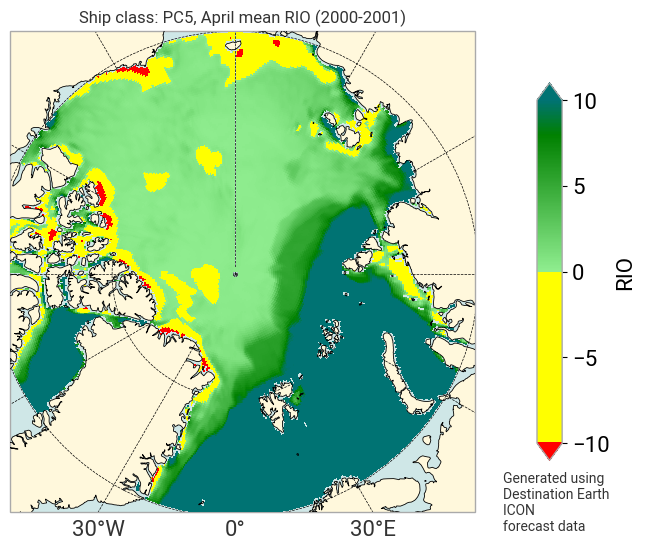

In [19]:
# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
# either set the axes background facecolor:
ax.set_facecolor(ocean_fc)
# (or use the ocean feature)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = plt.FixedLocator(range(40, 90, 10))
parallels.xlocator = plt.FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap=riomapAGI2, vmin=-10, vmax=10,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc. unchanged
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('RIO', fontsize=16)
plt.text(2400000,-2300000,'Generated using\nDestination Earth \n'+climateDTmodel+' \nforecast data',fontsize=10)    
plt.title(f"Ship class: {shipclass}, April mean RIO ({beginyear}-{endyear})")
plt.savefig(os.path.join(plotsdir, f"S2S_RIO_{shipclass}_april_mean_2000-2001.png"),
            dpi=300, bbox_inches="tight")


In [34]:
datatoplot=mean_arr_sep
lontoplot=lonrio
lattoplot=latrio


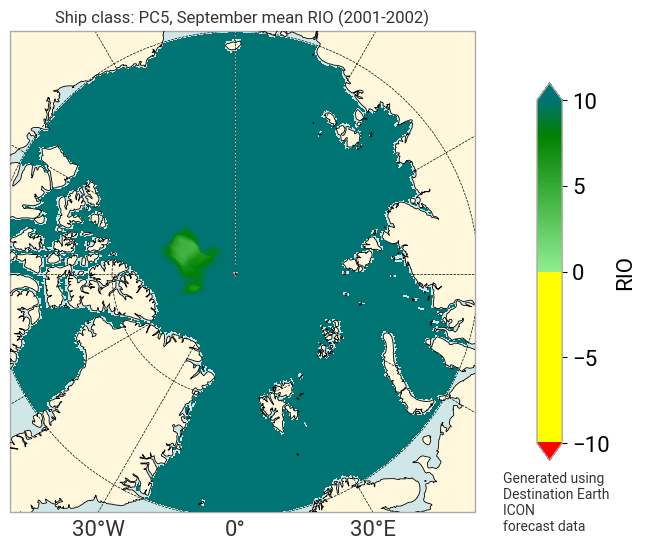

In [35]:
from matplotlib.ticker import FixedLocator  # <-- use this, not plt.FixedLocator

# --- colors (pick what you like) ---
ocean_fc = "#cfe7e7"
land_fc  = "cornsilk"

ax = plt.axes(projection=ccrs.Orthographic(central_longitude=0.0, central_latitude=90))
ax.set_extent([-180, 180, 70, 90], crs=ccrs.PlateCarree())

# 0) ocean base (lowest)
ax.set_facecolor(ocean_fc)
# ax.add_feature(cfeature.OCEAN, facecolor=ocean_fc, zorder=0)

# 1) land fill (below grid + RIO)
ax.add_feature(cfeature.LAND, facecolor=land_fc, edgecolor="none", zorder=1)

# 2) grid lines (above ocean+land, below RIO)
parallels = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color="black",
    alpha=1,
    linestyle="--",
    zorder=2,
)
parallels.ylocator = FixedLocator(range(40, 90, 10))
parallels.xlocator = FixedLocator(range(-180, 180, 30))
parallels.top_labels = False
parallels.xlabel_style = {'fontsize': 16}
parallels.ylabel_style = {'fontsize': 16}

# 3) RIO field (top of fills & grid)
pcolorhandle2 = ax.pcolormesh(
    lontoplot, lattoplot, datatoplot,
    cmap=riomapAGI2, vmin=-10, vmax=10,
    transform=ccrs.PlateCarree(),
    linewidth=0, rasterized=True,
    zorder=3,
)

# 4) coastlines on top for crisp edges
ax.coastlines(resolution="50m", linewidth=0.6, zorder=4)

# colorbar, title, etc.
cbar = plt.colorbar(pcolorhandle2, shrink=0.7, pad=0.1, aspect=15, extend='both')
cbar.ax.tick_params(labelsize=16)
cbar.set_label('RIO', fontsize=16)

plt.text(2400000, -2300000,
         'Generated using\nDestination Earth \n' + climateDTmodel + ' \nforecast data',
         fontsize=10)

plt.title(f"Ship class: {shipclass}, September mean RIO ({beginyear}-{endyear})")

plt.savefig(
    os.path.join(plotsdir, f"S2S_RIO_{shipclass}_september_mean_{beginyear}-{endyear}.png"),
    dpi=300, bbox_inches="tight"
)
